In [1]:
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import fastplot
import numpy as np
import seaborn as sns
import os
import json

%matplotlib inline

In [2]:
### SETUP

# Set to True if you have LaTeX locally installed and want to use it for plotting.
COMPILE_LATEX = True

if COMPILE_LATEX:
    plot_style = 'latex'
    CAIDA_SET = r"\textbf{\textsf{CAIDA}}"
    BGPKIT_SET = r"\textbf{\textsf{BGPKIT}}"
    ASPA_SET = r"\textbf{\textsf{ASPA}}"
    ASPAVIS_SET = r"\textbf{\textsf{ASPA}\textsubscript{\textsf{vis}}}"

else:
    plot_style = 'sans-serif'
    CAIDA_SET = "CAIDA"
    BGPKIT_SET = "BGPKIT"
    ASPA_SET = "ASPA"
    ASPAVIS_SET = "ASPA_vis"

# Extract `data/bgpkit.zip` if data/bgpkit does not exists
if not os.path.exists('data/bgpkit'):
    import zipfile
    with zipfile.ZipFile('data/bgpkit.zip', 'r') as zip_ref:
        zip_ref.extractall('data')

In [3]:
df = pd.read_csv('data/vaps.csv')
df['date'] = pd.to_datetime(df['date'])

df = df[(df['date'] >= '2026-03-01') & (df['date'] < '2026-03-06')]
df = df.drop_duplicates('customer', keep='last')

df['asn_customer'] = df['customer'].apply(lambda s: s[2:])

aspa = (
    df
        .set_index('asn_customer')
        ['providers']
        .apply(lambda prov: set(prov.replace('AS', '').split(' ')))
        .to_dict()
)

ASPA_CUSTOMERS = set(aspa.keys())

In [4]:
### Get aspa_vis, ~3 minutes

if os.path.exists('data/aspa_vis.json'):
    with open('data/aspa_vis.json', 'r') as f:
        aspa_vis = json.load(f)
        
    aspa_vis = {k: set(v) for k, v in aspa_vis.items()}

else:

    if not os.path.exists('data/caida/2026-03-paths.txt'):
        print("Error: `data/caida/2026-03-paths.txt` not found. \n"
                "To download it, run `python get_caida_data.py --paths`. \n"
                "Mind that the required file is 2.3 GB, when unzipped it's 43 GB, and the process will take a while.")
        exit(1)

    adjacent_asns = { customer: set() for customer in ASPA_CUSTOMERS }
    with open('data/caida/2026-03-paths.txt', 'r') as f:
        for line in f:
            path_str = line.strip()
            path = path_str.split('|')
            if len(set(path) & ASPA_CUSTOMERS) == 0:
                continue
            
            for i, asn in enumerate(path):
                if asn in ASPA_CUSTOMERS:
                    if i > 0:
                        adjacent_asns[asn].add(path[i - 1])
                    if i < len(path) - 1:
                        adjacent_asns[asn].add(path[i + 1])

    aspa_vis = { 
        customer: aspa[customer] & adjacent_asns[customer] 
        for customer in ASPA_CUSTOMERS 
    }

    with open('data/aspa_vis.json', 'w') as f:
        json.dump({k: list(v) for k, v in aspa_vis.items()}, f, indent=4)

In [5]:
_caida_prov_4 = (
    pd
        .read_csv('data/caida/2026-03-as-rel-v4.txt', 
                             sep='|', comment='#', header=None,  
                             names=['provider', 'customer', 'rel'],
                             dtype={'provider': str, 'customer': str, 'rel': int}
                 )
        .query('rel != 0')
        .query('customer in @ASPA_CUSTOMERS')
        .groupby('customer')
        ['provider']
        .agg(set)
        .to_dict()
)

_caida_prov_6 = (
    pd
        .read_csv('data/caida/2026-03-as-rel-v6.txt', 
                             sep='|', comment='#', header=None,  
                             names=['provider', 'customer', 'rel'],
                             dtype={'provider': str, 'customer': str, 'rel': int}
                 )
        .query('rel != 0')
        .query('customer in @ASPA_CUSTOMERS')
        .groupby('customer')
        ['provider']
        .agg(set)
        .to_dict()
)

caida = dict()
for customer in ASPA_CUSTOMERS:
    caida[customer] = set()
    caida[customer] |= _caida_prov_4.get(customer, set())
    caida[customer] |= _caida_prov_6.get(customer, set())

_bgpkit_prov_list = list()
for day in ('01', '02', '03', '04', '05'):
    _bgpkit_prov = (
        pd
            .read_json(f'data/bgpkit/as-rel_2026-03-{day}.json', dtype={'asn1': str, 'asn2': str})
            [['asn1', 'asn2', 'rel']]
            .rename(columns={'asn1': 'provider', 'asn2': 'customer'})
            .query('rel != 0')
            .query('customer in @ASPA_CUSTOMERS')
            .groupby('customer')
            ['provider']
            .agg(set)
            .to_dict()
    )
    _bgpkit_prov_list.append(_bgpkit_prov)

bgpkit = { customer: set() for customer in ASPA_CUSTOMERS }
for d in _bgpkit_prov_list:
    for customer, providers in d.items():
        bgpkit[customer] |= providers

# Provider sets size comparison

<Figure size 640x480 with 0 Axes>

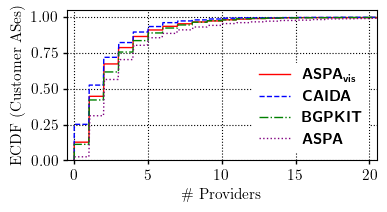

In [11]:
fastplot.plot([(ASPAVIS_SET, [len(v - {'0',}) for v in aspa_vis.values()]), 
                   (CAIDA_SET, [len(v) for v in caida.values()]), 
                   (BGPKIT_SET, [len(v) for v in bgpkit.values()]),
                   (ASPA_SET, [len(v - {'0',}) for v in aspa.values()])],
                  path=None, grid=True,
                  mode='CDF_multi', style=plot_style,
                  xtick_direction='out', ytick_direction='out',
                  legend=True, legend_loc='lower right', 
                  xlim=(-0.5, 20.5), ylim=(0, 1.05),
                  yticks=([0, 0.25, 0.5, 0.75, 1.0], None),
                  xlabel=r'\# Providers', ylabel='ECDF (Customer ASes)')

plt.savefig('figures/cdf_num_providers.pdf')

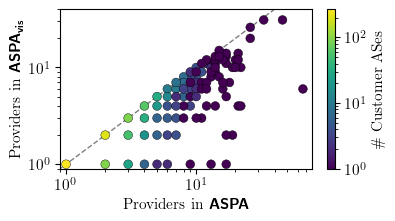

In [13]:
plt.rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
plt.rc('text', usetex=True)

x = []
y = []
for c in aspa:
    if aspa[c] == {'0'}:
        continue
    x.append(len(aspa[c]))
    y.append(len(aspa_vis[c]))

x = np.array(x)
y = np.array(y)

counts = Counter(zip(x, y))
xs, ys, cs = zip(*[(xi, yi, counts[(xi, yi)]) for xi, yi in counts])

fig, ax = plt.subplots(figsize=(4, 2.25))

lim = max(x.max(), y.max()) + 1
ax.plot([0, lim], [0, lim], color='gray', linestyle='--', linewidth=1, zorder=1)

sc = ax.scatter(xs, ys, c=cs, cmap='viridis', norm=plt.matplotlib.colors.LogNorm(),
                 s=40, edgecolors='black', linewidths=0.3, zorder=2)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label(r'\# Customer ASes')

ax.set_xlabel(r'Providers in \textbf{\textsf{ASPA}}')
ax.set_ylabel(r'Providers in \textbf{\textsf{ASPA}\textsubscript{\textsf{vis}}}')
ax.set_xlim(0.9, lim + 10)
ax.set_ylim(0.9, 40)
# ax.set_aspect('equal')
ax.set_xscale('log')
ax.set_yscale('log')


plt.tight_layout(pad=0.76)
plt.savefig('figures/aspa_vs_aspavis_scatter.pdf')
plt.show()

# Overall accuracy

In [ ]:
# Overall precision / recall / F1 score, both against aspa and against aspa_vis
for dataset in ('CAIDA', 'BGPKIT'):
    if dataset == 'CAIDA':
        infer_prov = caida
    elif dataset == 'BGPKIT':
        infer_prov = bgpkit
    
    tp = sum(len(infer_prov[c] & aspa[c]) for c in ASPA_CUSTOMERS if len(aspa_vis[c]) > 0)
    fp = sum(len(infer_prov[c] - aspa[c]) for c in ASPA_CUSTOMERS if len(aspa_vis[c]) > 0)
    fn = sum(len(aspa[c] - infer_prov[c]) for c in ASPA_CUSTOMERS if len(aspa_vis[c]) > 0)
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    print(f"{dataset} vs ASPA: Precision={precision:.2f}, Recall={recall:.2f}, F1={f1:.2f}")
    
    tp_star = sum(len(infer_prov[c] & aspa_vis[c]) for c in ASPA_CUSTOMERS if len(aspa_vis[c]) > 0)
    fp_star = sum(len(infer_prov[c] - aspa_vis[c]) for c in ASPA_CUSTOMERS if len(aspa_vis[c]) > 0)
    fn_star = sum(len(aspa_vis[c] - infer_prov[c]) for c in ASPA_CUSTOMERS if len(aspa_vis[c]) > 0)
    
    precision_star = tp_star / (tp_star + fp_star) if (tp_star + fp_star) > 0 else 0
    recall_star = tp_star / (tp_star + fn_star) if (tp_star + fn_star) > 0 else 0
    f1_star = 2 * (precision_star * recall_star) / (precision_star + recall_star) if (precision_star + recall_star) > 0 else 0
    
    print(f"{dataset} vs ASPA*: Precision={precision_star:.2f}, Recall={recall_star:.2f}, F1={f1_star:.2f}")

CAIDA vs ASPA: Precision=0.88, Recall=0.54, F1=0.67
CAIDA vs ASPA*: Precision=0.88, Recall=0.71, F1=0.79
BGPKIT vs ASPA: Precision=0.88, Recall=0.71, F1=0.78
BGPKIT vs ASPA*: Precision=0.87, Recall=0.93, F1=0.90


## False positives -> True positives
- Are there false positives that become true positives when accounting for updated ASPA objects over March?

In [10]:
fps_per_customer = {
    dataset: {
        c: (caida[c] - aspa[c]) if dataset == 'CAIDA' else (bgpkit[c] - aspa[c])
        for c in ASPA_CUSTOMERS
    }
    for dataset in ('CAIDA', 'BGPKIT')
}

In [19]:
df = pd.read_csv('data/vaps.csv')
df['date'] = pd.to_datetime(df['date'])

df = df[(df['date'] >= '2026-03-01') & (df['date'] < '2026-04-01')]
df = df.drop_duplicates('customer', keep='last')

df['asn_customer'] = df['customer'].apply(lambda s: s[2:])

aspa_updated = (
    df
        .set_index('asn_customer')
        ['providers']
        .apply(lambda prov: set(prov.replace('AS', '').split(' ')))
        .to_dict()
)

caida_updated_positives = 0
bgpkit_updated_positives = 0

for c, fps in fps_per_customer['CAIDA'].items():
    for fp in fps:
        if fp in aspa_updated[c]:
            caida_updated_positives += 1


for c, fps in fps_per_customer['BGPKIT'].items():
    for fp in fps:
        if fp in aspa_updated[c]:
            bgpkit_updated_positives += 1

print(f"CAIDA false positives that are actually true positives in updated ASPA objects: {caida_updated_positives}")
print(f"BGPKIT false positives that are actually true positives in updated ASPA objects: {bgpkit_updated_positives}")

CAIDA false positives that are actually true positives in updated ASPA objects: 7
BGPKIT false positives that are actually true positives in updated ASPA objects: 14


# Per-AS accuracy

In [ ]:
def get_heatmap_data(dataset, aspa_adjusted=False):
    inferred_providers = dict()
    
    if dataset.upper() == 'CAIDA':
        inferred_providers = caida
    elif dataset.upper() == 'BGPKIT':
        inferred_providers = bgpkit
    else:
        return dict()

    data = Counter()

    if aspa_adjusted:
        for customer, aspa_prov in aspa_vis.items():
            if len(aspa_vis[customer] - {'0',}) == 0:
                continue
            infer_prov = inferred_providers[customer]
            x = len(aspa_prov - infer_prov) # false negatives (ASPA providers missed by inference)
            y = len(infer_prov - aspa_prov) # false positives (Inferred providers not in ASPA)
            data[(x, y)] += 1
    else:
        for customer, aspa_prov in aspa.items():
            if len(aspa_vis[customer] - {'0',}) == 0:
                continue
            infer_prov = inferred_providers[customer]
            x = len(aspa_prov - infer_prov) # false negatives (ASPA providers missed by inference)
            y = len(infer_prov - aspa_prov) # false positives (Inferred providers not in ASPA)
            data[(x, y)] += 1

    return data

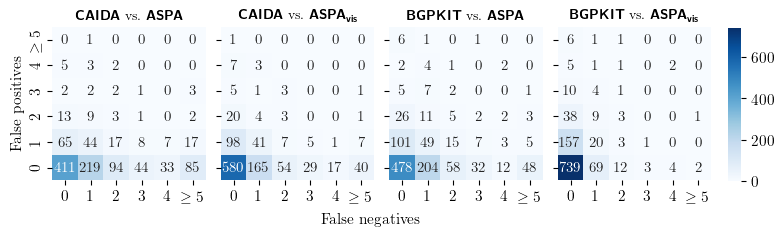

In [ ]:
XLIM = 4  # values >= 5 are aggregated in the last column
YLIM = 4  # values >= 5 are aggregated in the last row


def build_heatmap_matrix(dataset, aspa_adjusted, xlim=XLIM, ylim=YLIM):
    data = get_heatmap_data(dataset, aspa_adjusted=aspa_adjusted)
    matrix = np.zeros((ylim + 2, xlim + 2))

    for (x, y), count in data.items():
        xi = x if x <= xlim else xlim + 1
        yi = y if y <= ylim else ylim + 1
        matrix[yi, xi] += count

    return matrix

configs: list[tuple[str, bool, str]] = [
    ('CAIDA', False, fr'{CAIDA_SET} vs.\ {ASPA_SET}'),
    ('CAIDA', True, fr'{CAIDA_SET} vs.\ {ASPAVIS_SET}'),
    ('BGPKIT', False, fr'{BGPKIT_SET} vs.\ {ASPA_SET}'),
    ('BGPKIT', True, fr'{BGPKIT_SET} vs.\ {ASPAVIS_SET}'),
]

matrices = [build_heatmap_matrix(dataset, adjusted) for dataset, adjusted, _ in configs]
vmax = max(matrix.max() for matrix in matrices)

fig, axes = plt.subplots(1, 4, figsize=(8.5, 2.5), sharey=True, squeeze=True)
plt.subplots_adjust(wspace=0.1, right=0.9)

cbar_ax = fig.add_axes([0.92, 0.185, 0.015, 0.612])

fig.text(0.5, 0.06, 'False negatives', ha='center', va='top')

for i, (ax, matrix, (_, _, title)) in enumerate(zip(axes, matrices, configs)):
    sns.heatmap(
        matrix,
        ax=ax,
        annot=True,
        cmap='Blues',
        fmt='.3g',
        vmin=0,
        annot_kws={'fontsize': 10.75},
        vmax=vmax,
        square=True,
        cbar=(i == len(axes) - 1),
        cbar_ax=cbar_ax if i == len(axes) - 1 else None,
    )
    
    ax.invert_yaxis()
    ax.set_xticks(np.arange(XLIM + 2) + 0.5)
    ax.set_yticks(np.arange(YLIM + 2) + 0.5)

    if COMPILE_LATEX:
        ax.set_xticklabels([str(j) for j in range(XLIM + 1)] + [rf'$\ge {XLIM + 1}$'])
        ax.set_yticklabels([str(j) for j in range(YLIM + 1)] + [rf'$\ge {YLIM + 1}$'])
    else:
        ax.set_xticklabels([str(j) for j in range(XLIM + 1)] + [f'>= {XLIM + 1}'])
        ax.set_yticklabels([str(j) for j in range(YLIM + 1)] + [f'>= {YLIM + 1}'])

    ax.set_title(title, fontsize=10)


    ax.set_ylabel('False positives' if i == 0 else '')

plt.savefig('figures/combined_heatmap.pdf', bbox_inches='tight', pad_inches=0.1)